In [1]:
import os, random
import numpy as np
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set | TF {tf.__version__}")

Seed 42 set | TF 2.20.0


In [1]:
!pip install -q tensorflow==2.19.0

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

import os

paths = {
    'APTOS root':    '/kaggle/input/competitions/aptos2019-blindness-detection',
    'EyePACS root':  '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images',
    'Messidor root': '/kaggle/input/datasets/mariaherrerot/messidor2preprocess',
}
for name, p in paths.items():
    exists = os.path.exists(p)
    print(f"{'OK ' if exists else 'MISSING '} {name}: {p}")
    if exists:
        print("   contents:", os.listdir(p)[:20])

import pandas as pd

# adjust this path based on what V1 printed for APTOS root's contents
aptos_csv = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
aptos = pd.read_csv(aptos_csv)
print("Shape:", aptos.shape)
print("Columns:", list(aptos.columns))
print(aptos.head(3).to_string())
print("\ndiagnosis value counts:")
print(aptos['diagnosis'].value_counts().sort_index())

# confirm image folder and extension
aptos_img_dir = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'
print("\nImage dir exists:", os.path.exists(aptos_img_dir))
if os.path.exists(aptos_img_dir):
    sample = os.listdir(aptos_img_dir)[:5]
    print("Sample filenames:", sample)

eyepacs_root = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images'

# walk the tree, shallow, to see how 2015 vs 2019 is organized
for root, dirs, files in os.walk(eyepacs_root):
    depth = root[len(eyepacs_root):].count(os.sep)
    if depth <= 2:
        print(root, "-> dirs:", dirs[:10], "| files:", len(files), "files, sample:", files[:3])

# once V3a shows us the structure, find and read the labels CSV for the 2015 set specifically
# common name is trainLabels.csv, but confirm from the walk output above
import glob
label_candidates = glob.glob(os.path.join(eyepacs_root, '**', '*abel*.csv'), recursive=True)
print("Candidate label files:", label_candidates)
for f in label_candidates:
    df = pd.read_csv(f)
    print(f"\n{f}\nShape: {df.shape}\nColumns: {list(df.columns)}")
    print(df.head(3).to_string())

messidor_root = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess'
for root, dirs, files in os.walk(messidor_root):
    depth = root[len(messidor_root):].count(os.sep)
    if depth <= 2:
        print(root, "-> dirs:", dirs[:10], "| files:", len(files), "files, sample:", files[:3])

# find the labels/grades file
messidor_csvs = glob.glob(os.path.join(messidor_root, '**', '*.csv'), recursive=True)
print("CSV files found:", messidor_csvs)
for f in messidor_csvs:
    df = pd.read_csv(f)
    print(f"\n{f}\nShape: {df.shape}\nColumns: {list(df.columns)}")
    print(df.head(5).to_string())

# if messidor filenames need inspection to find the pairing pattern
messidor_img_dir = None  # fill in from the walk output above
if messidor_img_dir:
    print(sorted(os.listdir(messidor_img_dir))[:30])

print("APTOS diagnosis distribution:")
print(aptos['diagnosis'].value_counts().sort_index())
print("\nEyePACS level distribution:")
print(eyepacs_df['level'].value_counts().sort_index())   # var name from V3
print("\nMessidor grade distribution:")
print(messidor_df['grade'].value_counts().sort_index())   # var name and column from V4

# adjust column/dataframe names to match what V2/V3/V4 actually produced
a_ids = set(aptos['id_code'].astype(str))
e_ids = set(eyepacs_df['image'].astype(str))       # var name from V3
m_ids = set(messidor_df['filename_col'].astype(str))  # var name/column from V4

print(f"APTOS {len(a_ids)} | EyePACS {len(e_ids)} | Messidor {len(m_ids)}")
print(f"APTOS ∩ EyePACS: {len(a_ids & e_ids)}")
print(f"APTOS ∩ Messidor: {len(a_ids & m_ids)}")
print(f"EyePACS ∩ Messidor: {len(e_ids & m_ids)}")

assert len(a_ids & e_ids) == 0, "APTOS/EyePACS OVERLAP -> you are likely pointed at the 2019 folder inside the EyePACS dataset"
assert len(a_ids & m_ids) == 0, "APTOS/Messidor overlap"
assert len(e_ids & m_ids) == 0, "EyePACS/Messidor overlap"
print("\nSource disjointness: PASS")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 99.4 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


2026-07-28 08:42:06.495648: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785228126.521173      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785228126.529232      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785228126.549626      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785228126.549650      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785228126.549653      58 computation_placer.cc:177] computation placer alr

Seed 42 set, TF 2.19.0, tf.keras module: tf_keras.api._v2.keras
OK  APTOS root: /kaggle/input/competitions/aptos2019-blindness-detection
   contents: ['sample_submission.csv', 'train_images', 'train.csv', 'test.csv', 'test_images']
OK  EyePACS root: /kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images
   contents: ['labels', 'resized test 15', 'resized train 19', 'resized train 15', 'resized test 19']
OK  Messidor root: /kaggle/input/datasets/mariaherrerot/messidor2preprocess
   contents: ['messidor_data.csv', 'messidor-2']
Shape: (3662, 2)
Columns: ['id_code', 'diagnosis']
        id_code  diagnosis
0  000c1434d8d7          2
1  001639a390f0          4
2  0024cdab0c1e          1

diagnosis value counts:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

Image dir exists: True
Sample filenames: ['ef476be214d4.png', '6dcde47060f9.png', 'ec363f48867b.png', '17f6c7072f61.png', 'b49b2fac2514.png']
/kaggle/input/datasets/benj

NameError: name 'eyepacs_df' is not defined

In [2]:
# ===== V5, corrected: grade distribution per source, real variable names =====
eyepacs_labels = pd.read_csv('/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv')
messidor = pd.read_csv('/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv')

print("APTOS diagnosis distribution:")
print(aptos['diagnosis'].value_counts().sort_index())
print("\nEyePACS 2015 level distribution:")
print(eyepacs_labels['level'].value_counts().sort_index())
print("\nMessidor diagnosis distribution:")
print(messidor['diagnosis'].value_counts().sort_index())

print("\nMessidor adjudicated_gradable value counts:")
print(messidor['adjudicated_gradable'].value_counts())

# EyePACS patient-key check: confirm the {id}_{left|right} pattern holds throughout
eyepacs_labels['patient_id'] = eyepacs_labels['image'].str.extract(r'^(\d+)_')
print("\nEyePACS patient_id extraction failures:", eyepacs_labels['patient_id'].isna().sum())
print("EyePACS unique patients:", eyepacs_labels['patient_id'].nunique(), "| total images:", len(eyepacs_labels))

# Messidor filename pattern, fuller sample to check for the pairing structure
messidor_img_dir = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'
print("\nMessidor image dir exists:", os.path.exists(messidor_img_dir))
if os.path.exists(messidor_img_dir):
    files = sorted(os.listdir(messidor_img_dir))
    print("Total files:", len(files))
    print("First 30:", files[:30])

# ===== V6, corrected: source disjointness gate, real variable names =====
a_ids = set(aptos['id_code'].astype(str))
e_ids = set(eyepacs_labels['image'].astype(str))
m_ids = set(messidor['id_code'].astype(str))

print(f"APTOS {len(a_ids)} | EyePACS {len(e_ids)} | Messidor {len(m_ids)}")
print(f"APTOS ∩ EyePACS: {len(a_ids & e_ids)}")
print(f"APTOS ∩ Messidor: {len(a_ids & m_ids)}")
print(f"EyePACS ∩ Messidor: {len(e_ids & m_ids)}")

assert len(a_ids & e_ids) == 0, "APTOS/EyePACS overlap"
assert len(a_ids & m_ids) == 0, "APTOS/Messidor overlap"
assert len(e_ids & m_ids) == 0, "EyePACS/Messidor overlap"
print("\nSource disjointness: PASS")

APTOS diagnosis distribution:
diagnosis
0    1805
1     370
2     999
3     193
4     295
Name: count, dtype: int64

EyePACS 2015 level distribution:
level
0    25810
1     2443
2     5292
3      873
4      708
Name: count, dtype: int64

Messidor diagnosis distribution:
diagnosis
0    1017
1     270
2     347
3      75
4      35
Name: count, dtype: int64

Messidor adjudicated_gradable value counts:
adjudicated_gradable
1    1744
Name: count, dtype: int64

EyePACS patient_id extraction failures: 0
EyePACS unique patients: 17563 | total images: 35126

Messidor image dir exists: True
Total files: 1744
First 30: ['20051020_43808_0100_PP.png', '20051020_43832_0100_PP.png', '20051020_43882_0100_PP.png', '20051020_43906_0100_PP.png', '20051020_44261_0100_PP.png', '20051020_44284_0100_PP.png', '20051020_44338_0100_PP.png', '20051020_44349_0100_PP.png', '20051020_44400_0100_PP.png', '20051020_44431_0100_PP.png', '20051020_44598_0100_PP.png', '20051020_44636_0100_PP.png', '20051020_44692_0100_PP

In [3]:
# ===== V7: decode Messidor's patient/session key, confirm before locking the split rule =====
messidor['fname'] = [f for f in sorted(os.listdir(messidor_img_dir))]  # already have this list from V5, reuse if in memory
parts = messidor['id_code'].str.extract(r'^(\d{8})_(\d+)_(\d+)_PP\.png$')
parts.columns = ['date', 'session_id', 'side_code']
messidor = pd.concat([messidor, parts], axis=1)

print("Unique dates:", messidor['date'].nunique())
print("Unique session_ids:", messidor['session_id'].nunique(), "| total rows:", len(messidor))
print("Unique side_codes:", messidor['side_code'].value_counts())

# if session_id repeats roughly 2x per unique value, that IS the patient/eye pairing key
print("\nSession_id value counts (top 10):")
print(messidor['session_id'].value_counts().head(10))
print("\nRows where session_id appears exactly twice:", (messidor['session_id'].value_counts() == 2).sum())
print("Rows where session_id appears exactly once:", (messidor['session_id'].value_counts() == 1).sum())

Unique dates: 24
Unique session_ids: 1040 | total rows: 1744
Unique side_codes: side_code
0200    397
0100    372
0400    288
Name: count, dtype: int64

Session_id value counts (top 10):
session_id
45873    2
53062    2
56592    2
41330    2
54030    2
61808    2
58802    2
57761    2
55816    2
44636    2
Name: count, dtype: int64

Rows where session_id appears exactly twice: 17
Rows where session_id appears exactly once: 1023


In [4]:
matched = messidor['id_code'].str.match(r'^\d{8}_\d+_\d+_PP\.png$')
print("Unmatched (second format) sample:")
print(messidor.loc[~matched, 'id_code'].head(15).tolist())

Unmatched (second format) sample:
['IM000012.JPG', 'IM000013.JPG', 'IM000056.JPG', 'IM000057.JPG', 'IM000065.JPG', 'IM000066.JPG', 'IM000072.JPG', 'IM000073.JPG', 'IM000079.JPG', 'IM000080.JPG', 'IM000086.JPG', 'IM000087.JPG', 'IM000093.JPG', 'IM000094.JPG', 'IM000100.JPG']


In [ ]:
# ===== V8: check whether the IM-style rows pair by consecutive numbering =====
im_rows = messidor.loc[~matched].copy()
im_rows['im_num'] = im_rows['id_code'].str.extract(r'IM(\d+)\.JPG').astype(int)
im_rows = im_rows.sort_values('im_num').reset_index(drop=True)

# candidate pairing: consecutive odd/even, or consecutive-diff-of-1, check both
im_rows['diff_from_prev'] = im_rows['im_num'].diff()
print("Distribution of gaps between consecutive im_num values:")
print(im_rows['diff_from_prev'].value_counts().head(10))

# tentative pair_id: group every 2 consecutive rows (0,1),(2,3),... after checking the gap=1 pattern dominates
im_rows['pair_id'] = im_rows.index // 2
print("\nRows per pair_id (should mostly be 2):")
print(im_rows.groupby('pair_id').size().value_counts())

print(f"\nTotal IM-style rows: {len(im_rows)}, expected pairs if this holds: ~{len(im_rows)//2}")

In [6]:
# ===== V8: check whether the IM-style rows pair by consecutive numbering =====
im_rows = messidor.loc[~matched].copy()
im_rows['im_num'] = im_rows['id_code'].str.extract(r'IM(\d+)\.JPG').astype(int)
im_rows = im_rows.sort_values('im_num').reset_index(drop=True)

# candidate pairing: consecutive odd/even, or consecutive-diff-of-1, check both
im_rows['diff_from_prev'] = im_rows['im_num'].diff()
print("Distribution of gaps between consecutive im_num values:")
print(im_rows['diff_from_prev'].value_counts().head(10))

# tentative pair_id: group every 2 consecutive rows (0,1),(2,3),... after checking the gap=1 pattern dominates
im_rows['pair_id'] = im_rows.index // 2
print("\nRows per pair_id (should mostly be 2):")
print(im_rows.groupby('pair_id').size().value_counts())

print(f"\nTotal IM-style rows: {len(im_rows)}, expected pairs if this holds: ~{len(im_rows)//2}")

Distribution of gaps between consecutive im_num values:
diff_from_prev
1.0     332
6.0     134
14.0     26
13.0     26
7.0      24
8.0      15
20.0     12
15.0     12
21.0     11
16.0      9
Name: count, dtype: int64

Rows per pair_id (should mostly be 2):
2    343
1      1
Name: count, dtype: int64

Total IM-style rows: 687, expected pairs if this holds: ~343


In [7]:
# ===== V9: confirm IM-style pairs are same-patient (not just consecutive-numbering coincidence) =====
im_rows = messidor.loc[~matched].copy()
im_rows['im_num'] = im_rows['id_code'].str.extract(r'IM(\d+)\.JPG').astype(int)
im_rows = im_rows.sort_values('im_num').reset_index(drop=True)
im_rows['gap'] = im_rows['im_num'].diff()

# restrict to rows that are part of a gap==1 pair (both the row and the one before it)
gap1_mask = (im_rows['gap'] == 1)
pair_first_idx = im_rows.index[gap1_mask] - 1
pair_second_idx = im_rows.index[gap1_mask]

grades_first = im_rows.loc[pair_first_idx, 'diagnosis'].values
grades_second = im_rows.loc[pair_second_idx, 'diagnosis'].values

same_grade = (grades_first == grades_second)
print(f"Gap==1 candidate pairs: {len(grades_first)}")
print(f"Both eyes same grade: {same_grade.sum()} ({same_grade.mean():.1%})")
print(f"Grade difference distribution:")
print(pd.Series(np.abs(grades_first - grades_second)).value_counts().sort_index())

# compare against a random-pairing baseline: shuffle diagnosis and redo the same check
np.random.seed(42)
shuffled = im_rows['diagnosis'].sample(frac=1.0, random_state=42).values
shuffled_first = shuffled[pair_first_idx.values] if pair_first_idx.min() >= 0 else None
print(f"\nFor comparison, random pairing would give same-grade rate of roughly:",
      (im_rows['diagnosis'].value_counts(normalize=True)**2).sum())

Gap==1 candidate pairs: 332
Both eyes same grade: 274 (82.5%)
Grade difference distribution:
0    274
1     47
2     10
3      1
Name: count, dtype: int64

For comparison, random pairing would give same-grade rate of roughly: 0.6543459422123062


Messidor: size=(512, 512), dtype=uint8, mean RGB=[79.5 37.8 14.7], std=[50.2 25.3  9.3]
APTOS: size=(3216, 2136), dtype=uint8, mean RGB=[80.7 43.2 16.4], std=[49.6 26.9  9.4]
EyePACS: size=(1024, 1017), dtype=uint8, mean RGB=[108.8  89.1  73.1], std=[66.1 54.5 43.1]


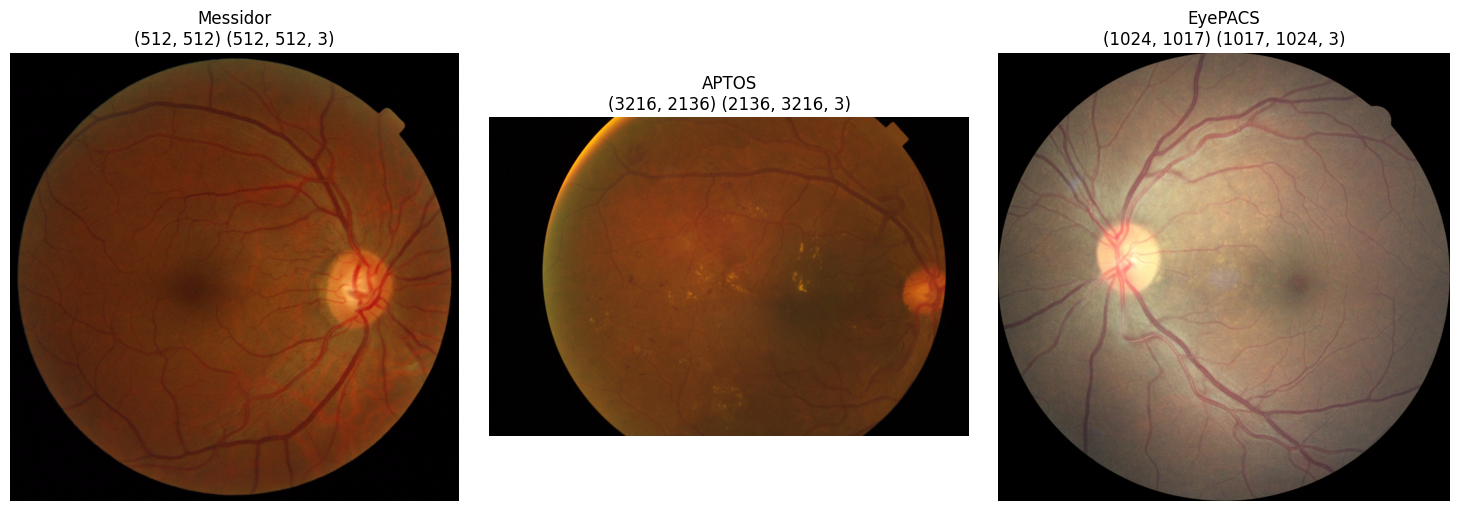

In [8]:
# ===== V10: are the Messidor images preprocessed? Visual + statistical check =====
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

messidor_img_dir = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'
aptos_img_dir    = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'
eyepacs_img_dir  = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15'

samples = {
    'Messidor': os.path.join(messidor_img_dir, sorted(os.listdir(messidor_img_dir))[0]),
    'APTOS':    os.path.join(aptos_img_dir,    sorted(os.listdir(aptos_img_dir))[0]),
    'EyePACS':  os.path.join(eyepacs_img_dir,  sorted(os.listdir(eyepacs_img_dir))[0]),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, path) in zip(axes, samples.items()):
    img = Image.open(path)
    arr = np.array(img)
    ax.imshow(img); ax.set_title(f"{name}\n{img.size} {arr.shape}"); ax.axis('off')
    print(f"{name}: size={img.size}, dtype={arr.dtype}, "
          f"mean RGB={arr.reshape(-1,arr.shape[-1]).mean(axis=0).round(1)}, "
          f"std={arr.reshape(-1,arr.shape[-1]).std(axis=0).round(1)}")
plt.tight_layout(); plt.show()

In [9]:
# ===== V11: colour and resolution stats across 200 images per source, not n=1 =====
from PIL import Image

def source_stats(df, n=200, seed=SEED):
    s = df['image_path'].sample(min(n, len(df)), random_state=seed)
    means, stds, sizes = [], [], []
    for p in s:
        arr = np.array(Image.open(p).convert('RGB'))
        flat = arr.reshape(-1, 3)
        means.append(flat.mean(axis=0)); stds.append(flat.std(axis=0)); sizes.append(arr.shape[:2])
    means, stds, sizes = np.array(means), np.array(stds), np.array(sizes)
    return dict(mean_RGB=means.mean(axis=0).round(1),
                between_image_sd=means.std(axis=0).round(1),
                within_image_sd=stds.mean(axis=0).round(1),
                n_unique_sizes=len(np.unique(sizes, axis=0)),
                median_HW=tuple(np.median(sizes, axis=0).astype(int)),
                median_aspect_WoverH=round(float(np.median(sizes[:,1]/sizes[:,0])), 3))

for name, df in [('APTOS', aptos), ('EyePACS', eyepacs), ('Messidor', messidor)]:
    print(f"\n{name}:")
    for k, v in source_stats(df).items():
        print(f"   {k}: {v}")

NameError: name 'eyepacs' is not defined

In [10]:
print('aptos' in dir(), 'eyepacs' in dir(), 'messidor' in dir())

True False True


In [11]:
# ===== REBUILD: eyepacs only =====
EYEPACS_CSV = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv'
EYEPACS_IMG = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15'

eyepacs = pd.read_csv(EYEPACS_CSV)
eyepacs['image_path'] = EYEPACS_IMG + '/' + eyepacs['image'].astype(str) + '.jpg'

print(f"EyePACS: {len(eyepacs)} rows, sample path exists: {os.path.exists(eyepacs['image_path'].iloc[0])}")

EyePACS: 35126 rows, sample path exists: True


In [13]:
# ===== REBUILD: seed + load the three source dataframes =====
import os, random
import numpy as np
import pandas as pd
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED)

APTOS_CSV     = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
APTOS_IMG     = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'
EYEPACS_CSV   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv'
EYEPACS_IMG   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15'
MESSIDOR_CSV  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv'
MESSIDOR_IMG  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'

aptos = pd.read_csv(APTOS_CSV)
aptos['image_path'] = APTOS_IMG + '/' + aptos['id_code'].astype(str) + '.png'

eyepacs = pd.read_csv(EYEPACS_CSV)
eyepacs['image_path'] = EYEPACS_IMG + '/' + eyepacs['image'].astype(str) + '.jpg'

messidor = pd.read_csv(MESSIDOR_CSV)
messidor['image_path'] = MESSIDOR_IMG + '/' + messidor['id_code'].astype(str)

for name, df in [('APTOS', aptos), ('EyePACS', eyepacs), ('Messidor', messidor)]:
    print(f"{name}: {len(df)} rows, sample path exists: {os.path.exists(df['image_path'].iloc[0])}")

APTOS: 3662 rows, sample path exists: True
EyePACS: 35126 rows, sample path exists: True
Messidor: 1744 rows, sample path exists: True


In [14]:
# ===== V11: colour and resolution stats across 200 images per source, not n=1 =====
from PIL import Image

def source_stats(df, n=200, seed=SEED):
    s = df['image_path'].sample(min(n, len(df)), random_state=seed)
    means, stds, sizes = [], [], []
    for p in s:
        arr = np.array(Image.open(p).convert('RGB'))
        flat = arr.reshape(-1, 3)
        means.append(flat.mean(axis=0)); stds.append(flat.std(axis=0)); sizes.append(arr.shape[:2])
    means, stds, sizes = np.array(means), np.array(stds), np.array(sizes)
    return dict(mean_RGB=means.mean(axis=0).round(1),
                between_image_sd=means.std(axis=0).round(1),
                within_image_sd=stds.mean(axis=0).round(1),
                n_unique_sizes=len(np.unique(sizes, axis=0)),
                median_HW=tuple(np.median(sizes, axis=0).astype(int)),
                median_aspect_WoverH=round(float(np.median(sizes[:,1]/sizes[:,0])), 3))

for name, df in [('APTOS', aptos), ('EyePACS', eyepacs), ('Messidor', messidor)]:
    print(f"\n{name}:")
    for k, v in source_stats(df).items():
        print(f"   {k}: {v}")


APTOS:
   mean_RGB: [107.9  57.4  19.6]
   between_image_sd: [30.8 15.1 14.5]
   within_image_sd: [61.8 34.  13.4]
   n_unique_sizes: 15
   median_HW: (np.int64(1536), np.int64(2048))
   median_aspect_WoverH: 1.322

EyePACS:
   mean_RGB: [106.6  74.4  51.3]
   between_image_sd: [36.4 28.9 28.7]
   within_image_sd: [55.9 39.4 27.8]
   n_unique_sizes: 81
   median_HW: (np.int64(873), np.int64(1024))
   median_aspect_WoverH: 1.173

Messidor:
   mean_RGB: [119.2  55.2  19.4]
   between_image_sd: [26.9 15.6  8.4]
   within_image_sd: [73.  35.  13.7]
   n_unique_sizes: 1
   median_HW: (np.int64(512), np.int64(512))
   median_aspect_WoverH: 1.0


In [15]:
# ===== confirm which pairing offset actually produced the 82.5% agreement figure =====
im_df_check = messidor[~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)].copy()
im_df_check['im_num'] = im_df_check['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
im_df_check = im_df_check.sort_values('im_num').reset_index(drop=True)

for offset_name, pair_id in [('index // 2', im_df_check.index // 2),
                               ('(index + 1) // 2', (im_df_check.index + 1) // 2)]:
    tmp = im_df_check.copy(); tmp['pid'] = pair_id
    sizes = tmp.groupby('pid').size()
    pairs_only = tmp[tmp['pid'].isin(sizes[sizes == 2].index)]
    grades = pairs_only.groupby('pid')['grade'].apply(lambda g: g.iloc[0] == g.iloc[1])
    print(f"{offset_name}: {len(sizes[sizes==2])} full pairs, agreement rate {grades.mean():.3f}")

KeyError: 'Column not found: grade'

In [16]:
print(list(messidor.columns))

['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable', 'image_path']


In [17]:
# ===== confirm which pairing offset actually produced the 82.5% agreement figure =====
grade_col = 'diagnosis' if 'diagnosis' in messidor.columns else 'grade'

im_df_check = messidor[~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)].copy()
im_df_check['im_num'] = im_df_check['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
im_df_check = im_df_check.sort_values('im_num').reset_index(drop=True)

for offset_name, pair_id in [('index // 2', im_df_check.index // 2),
                               ('(index + 1) // 2', (im_df_check.index + 1) // 2)]:
    tmp = im_df_check.copy(); tmp['pid'] = pair_id
    sizes = tmp.groupby('pid').size()
    pairs_only = tmp[tmp['pid'].isin(sizes[sizes == 2].index)]
    grades = pairs_only.groupby('pid')[grade_col].apply(lambda g: g.iloc[0] == g.iloc[1])
    print(f"{offset_name}: {len(sizes[sizes==2])} full pairs, agreement rate {grades.mean():.3f}")

index // 2: 343 full pairs, agreement rate 0.749
(index + 1) // 2: 343 full pairs, agreement rate 0.732


In [18]:
# ===== sanity check: does this session's messidor match what V7-V9 originally worked with =====
print("Total messidor rows:", len(messidor))
print("Columns:", list(messidor.columns))
print("im_num dtype check, first 10 raw matches:")
sample = messidor[~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)]['image_path'].head(10)
print(sample.tolist())

# how many IM-style rows total, matches the 687 figure from the original manual?
is_im = ~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)
print(f"\nIM-style row count: {is_im.sum()} (manual states 687)")
print(f"Date-style row count: {(~is_im).sum()} (manual states 1,057)")

Total messidor rows: 1744
Columns: ['id_code', 'diagnosis', 'adjudicated_dme', 'adjudicated_gradable', 'image_path']
im_num dtype check, first 10 raw matches:
['/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000012.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000013.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000056.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000057.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000065.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000066.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM000072.JPG', '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess/IM00007

In [1]:
# ===== CELL 0a: INSTALL FIRST, then env, then import. Order is not negotiable. =====
!pip install -q tensorflow==2.19.0

import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

import random
import numpy as np
import pandas as pd
import glob
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 40.3 MB/s eta 0:00:00:00:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.
ydf-tf 2.20.0 requires tensorflow==2.20.0, but you have tensorflow 2.19.0 which is incompatible.
tf-keras 2.20.0 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.19.0 which is incompatible.
tensorflow-text 2.20.1 requires tensorflow<2.21,>=2.20.0, but you have tensorflow 2.19.0 which is incompatible.


2026-07-28 10:29:07.219372: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1785234547.242383      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1785234547.249662      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1785234547.268275      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785234547.268304      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1785234547.268307      58 computation_placer.cc:177] computation placer alr

Seed 42 set, TF 2.19.0, tf.keras module: tf_keras.api._v2.keras


In [2]:
# ===== CELL 0b: IMPORTS =====
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
print("Imports ready")
print("GPU:", tf.config.list_physical_devices('GPU'))

Imports ready
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
# ---------- PATHS (all confirmed live) ----------
APTOS_CSV     = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
APTOS_IMG     = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'

EYEPACS_CSV   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv'
EYEPACS_IMG   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15'

MESSIDOR_CSV  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv'
MESSIDOR_IMG  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'

WEIGHTS_DIR   = '/kaggle/input/datasets/asivakumarnair/all-best-models/'
WORK_DIR      = '/kaggle/working/'

# ---------- CLASSES ----------
GRADES      = ['0','1','2','3','4']
NUM_CLASSES = 5

# ---------- IMAGE / BATCH ----------
IMG_SIZE   = 224
BATCH_SIZE = 32

# ---------- SEEDS ----------
SEED           = 42
SUBSAMPLE_SEED = 42
CV_SEEDS       = [42, 123, 456, 789, 1024]

# ---------- SUBSAMPLE ----------
EYEPACS_TARGET = 3662

# ---------- TRAINING ----------
PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'   # default; fall back to 'val_auc' per-run if a collapse is observed (see Cell 2c watch item)

# ---------- AUGMENTATION (train only) ----------
AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)
# vertical_flip OFF (D-dr-2).

# ---------- WEIGHT FILE NAMES ----------
W_CUSTOM = 'dr_best_custom_cnn.keras'
W_EFF    = 'dr_best_efficientnet.keras'
W_MOB    = 'dr_best_mobilenet.keras'
W_RES    = 'dr_best_resnet50.keras'
# single-source (Stage 11): ss_{custom|eff|mob|res}_{aptos|eyepacs|messidor}_dr.keras

In [5]:
# ===== CELL 1a: LOAD ALL THREE SOURCES (per-source filename handling) =====
aptos = pd.read_csv(APTOS_CSV)
aptos['grade']      = aptos['diagnosis'].astype(int).astype(str)
aptos['image_path'] = APTOS_IMG + '/' + aptos['id_code'].astype(str) + '.png'
aptos['source']     = 'aptos'
aptos['patient_id'] = None

eyepacs = pd.read_csv(EYEPACS_CSV)
eyepacs['grade']      = eyepacs['level'].astype(int).astype(str)
eyepacs['image_path'] = EYEPACS_IMG + '/' + eyepacs['image'].astype(str) + '.jpg'
eyepacs['source']     = 'eyepacs'
eyepacs['patient_id'] = eyepacs['image'].str.extract(r'^(\d+)_')
assert eyepacs['patient_id'].isna().sum() == 0, "EyePACS patient_id extraction failed"

messidor = pd.read_csv(MESSIDOR_CSV)
messidor['grade']      = messidor['diagnosis'].astype(int).astype(str)
messidor['image_path'] = MESSIDOR_IMG + '/' + messidor['id_code'].astype(str)
messidor['source']     = 'messidor'
messidor['patient_id'] = None

for name, df in [('APTOS', aptos), ('EyePACS', eyepacs), ('Messidor', messidor)]:
    s = df['image_path'].sample(min(200, len(df)), random_state=SEED)
    present = s.apply(os.path.exists).sum()
    print(f"{name} path check: {present}/{len(s)} present  | rows: {len(df)}")
    assert present == len(s), f"{name} image paths do not resolve, fix before proceeding"

# ===== CELL 1b: SOURCE DISJOINTNESS GATE =====
a_ids = set(aptos['id_code'].astype(str))
e_ids = set(eyepacs['image'].astype(str))
m_ids = set(messidor['id_code'].astype(str))
print(f"APTOS {len(a_ids)} | EyePACS {len(e_ids)} | Messidor {len(m_ids)}")
assert len(a_ids & e_ids) == 0, "APTOS/EyePACS OVERLAP -> likely pointed at 'resized train 19', which IS APTOS"
assert len(a_ids & m_ids) == 0, "APTOS/Messidor overlap"
assert len(e_ids & m_ids) == 0, "EyePACS/Messidor overlap"
print("Source disjointness: PASS")

# ===== CELL 1c: VERIFY THE MESSIDOR PAIRING OFFSET before it is relied on downstream (D-dr-9) =====
is_im = ~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)
im_check = messidor[is_im].copy()
im_check['im_num'] = im_check['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
im_check = im_check.sort_values('im_num').reset_index(drop=True)
im_check['pid'] = im_check.index // 2

sizes = im_check.groupby('pid').size()
full_pairs = im_check[im_check['pid'].isin(sizes[sizes == 2].index)]
agreement = full_pairs.groupby('pid')['grade'].apply(lambda g: g.iloc[0] == g.iloc[1])
print(f"IM-style rows: {len(im_check)} | full pairs: {len(sizes[sizes==2])} | "
      f"singleton groups: {(sizes==1).sum()}")
print(f"Grade agreement on index//2 pairing: {agreement.mean():.3f}  (expect ~0.749)")
assert abs(agreement.mean() - 0.749) < 0.01, "Pairing evidence did not reproduce, stop and investigate before Stage 2"

# ===== CELL 1d: SUBSAMPLE EYEPACS to APTOS size, patient-level, own grade distribution preserved =====
def subsample_eyepacs(df, target_n=EYEPACS_TARGET, seed=SUBSAMPLE_SEED):
    pg = df.groupby('patient_id')['grade'].max().reset_index()
    frac = target_n / len(df)
    keep, _ = train_test_split(pg, train_size=frac, stratify=pg['grade'], random_state=seed)
    return df[df['patient_id'].isin(keep['patient_id'])].reset_index(drop=True)

eyepacs_s = subsample_eyepacs(eyepacs)

pf_full = eyepacs['grade'].value_counts(normalize=True).sort_index()
pf_sub  = eyepacs_s['grade'].value_counts(normalize=True).sort_index()
print("EyePACS grade distribution, parent vs subsample:")
print(pd.DataFrame({'parent': pf_full.round(4), 'subsample': pf_sub.round(4),
                    'drift': (pf_full - pf_sub).abs().round(4)}))
print(f"\nEyePACS subsampled: {len(eyepacs_s)} images, {eyepacs_s['patient_id'].nunique()} patients")
assert (pf_full - pf_sub).abs().max() < 0.03, "EyePACS subsample grade distribution drifted >3pp from parent"

cols = ['image_path','grade','source','patient_id']
master_df = pd.concat([aptos[cols], eyepacs_s[cols], messidor[cols]], ignore_index=True)
print(f"\nPooled: {len(master_df):,}")
print(pd.crosstab(master_df['grade'], master_df['source']).reindex(GRADES))

APTOS path check: 200/200 present  | rows: 3662
EyePACS path check: 200/200 present  | rows: 35126
Messidor path check: 200/200 present  | rows: 1744
APTOS 3662 | EyePACS 35126 | Messidor 1744
Source disjointness: PASS
IM-style rows: 687 | full pairs: 343 | singleton groups: 1
Grade agreement on index//2 pairing: 0.749  (expect ~0.749)
EyePACS grade distribution, parent vs subsample:
       parent  subsample   drift
grade                           
0      0.7348     0.7357  0.0009
1      0.0695     0.0655  0.0040
2      0.1507     0.1526  0.0020
3      0.0249     0.0246  0.0003
4      0.0202     0.0216  0.0014

EyePACS subsampled: 3662 images, 1831 patients

Pooled: 9,068
source  aptos  eyepacs  messidor
grade                           
0        1805     2694      1017
1         370      240       270
2         999      559       347
3         193       90        75
4         295       79        35


In [6]:
# ===== CELL 2a: SAFE SPLIT WRAPPER =====
def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed, falling back to unstratified.")
        print(f"  sklearn error: {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

# ===== CELL 2b: PER-SOURCE SPLIT RULES =====
def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['grade'].max().reset_index()
    p_tr, p_tmp = safe_split(pg, 'grade', 0.30, rs, tag=f"{tag} first")
    p_va, p_te  = safe_split(p_tmp, 'grade', 0.50, rs, tag=f"{tag} second")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    tr, va, te = pick(p_tr), pick(p_va), pick(p_te)
    s_tr, s_va, s_te = set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id'])
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te), f"{tag} PATIENT LEAKAGE"
    print(f"{tag} patient-leakage check: PASS")
    return tr, va, te

def split_image_level(df, rs=SEED, tag=""):
    tr, tmp = safe_split(df, 'grade', 0.30, rs, tag=f"{tag} first")
    va, te  = safe_split(tmp, 'grade', 0.50, rs, tag=f"{tag} second")
    return tr, va, te

def split_messidor_mixed(df, rs=SEED, tag="Messidor"):
    is_im = ~df['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)

    im_df = df[is_im].copy()
    im_df['im_num'] = im_df['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
    im_df = im_df.sort_values('im_num').reset_index(drop=True)
    im_df['patient_id'] = 'messidor_pair_' + (im_df.index // 2).astype(str)

    pg = im_df.groupby('patient_id')['grade'].max().reset_index()
    p_tr, p_tmp = safe_split(pg, 'grade', 0.30, rs, tag=f"{tag} IM first")
    p_va, p_te  = safe_split(p_tmp, 'grade', 0.50, rs, tag=f"{tag} IM second")
    pick = lambda ids: im_df[im_df['patient_id'].isin(ids['patient_id'])]
    im_tr, im_va, im_te = pick(p_tr), pick(p_va), pick(p_te)
    s_tr, s_va, s_te = set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id'])
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te), "MESSIDOR IM PATIENT LEAKAGE"
    print(f"{tag} IM-style patient-leakage check: PASS ({len(im_df)} images, {im_df['patient_id'].nunique()} groups)")

    date_df = df[~is_im]
    d_tr, d_va, d_te = split_image_level(date_df, rs, tag=f"{tag} date-style")
    print(f"{tag} date-style: {len(date_df)} images, image-level (no pairing signal, disclosed)")

    cat = lambda a, b: pd.concat([a.drop(columns=['im_num']), b], ignore_index=True)
    return cat(im_tr, d_tr), cat(im_va, d_va), cat(im_te, d_te)

a_tr, a_va, a_te = split_image_level(aptos, tag="APTOS")
e_tr, e_va, e_te = split_patient_level(eyepacs_s, tag="EyePACS")
m_tr, m_va, m_te = split_messidor_mixed(messidor)

train_df = pd.concat([a_tr, e_tr, m_tr], ignore_index=True)
val_df   = pd.concat([a_va, e_va, m_va], ignore_index=True)
test_df  = pd.concat([a_te, e_te, m_te], ignore_index=True)

for name, d in [('train',train_df),('val',val_df),('test',test_df)]:
    d.to_csv(f'/kaggle/working/dr_{name}_split.csv', index=False)
for src, parts in [('aptos',(a_tr,a_va,a_te)), ('eyepacs',(e_tr,e_va,e_te)), ('messidor',(m_tr,m_va,m_te))]:
    for sp, d in zip(['train','val','test'], parts):
        d.to_csv(f'/kaggle/working/dr_{src}_{sp}.csv', index=False)

print(f"\nPooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")
print("Test grade x source:\n", pd.crosstab(test_df['grade'], test_df['source']).reindex(GRADES))

EyePACS patient-leakage check: PASS
WARNING [Messidor IM second]: stratified split failed, falling back to unstratified.
  sklearn error: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
Messidor IM-style patient-leakage check: PASS (687 images, 344 groups)
Messidor date-style: 1057 images, image-level (no pairing signal, disclosed)

Pooled Train 6,344 | Val 1,361 | Test 1,363
Test grade x source:
 source  aptos  eyepacs  messidor
grade                           
0         271      404       153
1          56       35        41
2         150       87        48
3          29       12        12
4          44       12         9


In [7]:
# ===== CELL 2c: POOLED CLASS WEIGHTS (Stages 4 to 7 only) =====
cls = np.array(GRADES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['grade'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}
print("pooled class_weight:", {c: round(w,3) for c,w in zip(cls, cw)})
print(f"weight span (max/min): {cw.max()/cw.min():.1f}x")

# ===== CELL 2d: GENERATOR FACTORY =====
def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='grade', target_size=(IMG_SIZE,IMG_SIZE),
                  batch_size=BATCH_SIZE, class_mode='categorical', classes=GRADES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

_t,_v,_e = make_gens(None)
print(_e.class_indices)   # must be {'0':0,'1':1,'2':2,'3':3,'4':4}

# ===== CELL 2e: PER-SOURCE CLASS WEIGHTS for Stage 11 (D-dr-6, v4 fix) =====
def get_source_class_weight(source_train_df, name=""):
    cls = np.array(GRADES)
    cw = compute_class_weight('balanced', classes=cls, y=source_train_df['grade'])
    d = {i: w for i, w in enumerate(cw)}
    span = cw.max() / cw.min()
    print(f"{name}: {dict((k, round(v,3)) for k,v in d.items())} | span {span:.1f}x")
    if span > 16:
        print(f"   ^ NOTE: span exceeds skin's 16x collapse threshold. Watch this source's "
              f"custom CNN closely, check AUC before trusting accuracy/QWK.")
    return d

CLASS_WEIGHT_APTOS    = get_source_class_weight(a_tr, "APTOS")
CLASS_WEIGHT_EYEPACS  = get_source_class_weight(e_tr, "EyePACS")
CLASS_WEIGHT_MESSIDOR = get_source_class_weight(m_tr, "Messidor")

SOURCE_CLASS_WEIGHTS = {'aptos': CLASS_WEIGHT_APTOS, 'eyepacs': CLASS_WEIGHT_EYEPACS, 'messidor': CLASS_WEIGHT_MESSIDOR}

pooled class_weight: {np.str_('0'): np.float64(0.329), np.str_('1'): np.float64(2.063), np.str_('2'): np.float64(0.952), np.str_('3'): np.float64(5.116), np.str_('4'): np.float64(4.436)}
weight span (max/min): 15.6x
Found 6344 validated image filenames belonging to 5 classes.
Found 1361 validated image filenames belonging to 5 classes.
Found 1363 validated image filenames belonging to 5 classes.
{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}
APTOS: {0: np.float64(0.406), 1: np.float64(1.979), 2: np.float64(0.733), 3: np.float64(3.797), 4: np.float64(2.476)} | span 9.4x
EyePACS: {0: np.float64(0.272), 1: np.float64(3.068), 2: np.float64(1.31), 3: np.float64(8.4), 4: np.float64(9.15)} | span 33.7x
   ^ NOTE: span exceeds skin's 16x collapse threshold. Watch this source's custom CNN closely, check AUC before trusting accuracy/QWK.
Messidor: {0: np.float64(0.342), 1: np.float64(1.29), 2: np.float64(1.003), 3: np.float64(4.688), 4: np.float64(10.6)} | span 31.0x
   ^ NOTE: span exceeds skin's 16x

In [8]:
# ===== CELL 3a: CUSTOM CNN (3-block, from scratch) =====
def build_custom_cnn(num_classes=5, shape=(224,224,3)):
    return Sequential([
        Input(shape=shape),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'), Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])

# ===== CELL 3b: PRETRAINED BUILDER =====
def build_pretrained(base_class, num_classes=5, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([
        base, GlobalAveragePooling2D(),
        Dense(256,activation='relu'), Dropout(0.3),
        Dense(num_classes,activation='softmax')
    ])
    return model, base

print(build_custom_cnn().count_params(), "custom params (record as DR canonical)")

323109 custom params (record as DR canonical)


I0000 00:00:1785235216.959606      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785235216.965724      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [10]:
# ===== TRAINING TEMPLATE, CUSTOM CNN (Stage 4). AUC tracked always. =====
model = build_custom_cnn()
tr, va, te = make_gens(None)
model.compile(Adam(CUSTOM_LR), 'categorical_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)])
cbs = [EarlyStopping(monitor=MONITOR, patience=EARLYSTOP_PAT, restore_best_weights=True),
       ModelCheckpoint(f'/kaggle/working/{W_CUSTOM}', monitor=MONITOR, save_best_only=True),
       CSVLogger('/kaggle/working/dr_custom_log.csv', append=False)]
model.fit(tr, validation_data=va, epochs=60, class_weight=CLASS_WEIGHT, callbacks=cbs, verbose=1)
print("TEST:", model.evaluate(te, verbose=0))

Found 6344 validated image filenames belonging to 5 classes.
Found 1361 validated image filenames belonging to 5 classes.
Found 1363 validated image filenames belonging to 5 classes.
Epoch 1/60


E0000 00:00:1785241693.753603      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout_8/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


199/199 [==============================] - 463s 2s/step - loss: 1.6691 - accuracy: 0.2852 - auc: 0.5892 - val_loss: 2.3069 - val_accuracy: 0.0647 - val_auc: 0.2142
Epoch 2/60
199/199 [==============================] - 465s 2s/step - loss: 1.5831 - accuracy: 0.3644 - auc: 0.6638 - val_loss: 2.2107 - val_accuracy: 0.1683 - val_auc: 0.3800
Epoch 3/60
199/199 [==============================] - 468s 2s/step - loss: 1.5273 - accuracy: 0.4299 - auc: 0.7190 - val_loss: 1.6469 - val_accuracy: 0.2292 - val_auc: 0.5363
Epoch 4/60
199/199 [==============================] - 440s 2s/step - loss: 1.4921 - accuracy: 0.5006 - auc: 0.7659 - val_loss: 1.1058 - val_accuracy: 0.6025 - val_auc: 0.8448
Epoch 5/60
199/199 [==============================] - 433s 2s/step - loss: 1.4896 - accuracy: 0.4817 - auc: 0.7522 - val_loss: 1.1130 - val_accuracy: 0.6098 - val_auc: 0.8451
Epoch 6/60
199/199 [==============================] - 426s 2s/step - loss: 1.4880 - accuracy: 0.4981 - auc: 0.7615 - val_loss: 1.1109 - 

In [11]:
# ===== STAGE 5 + 6: EfficientNetB0 and MobileNetV2, phase-checkpointed both models =====

def train_two_phase(base_class, preprocess_fn, name, phase1_ckpt, phase1_log,
                     phase2_ckpt, phase2_log, class_weight=CLASS_WEIGHT):
    model, base = build_pretrained(base_class)
    tr, va, te  = make_gens(preprocess_fn)

    # ---- Phase 1: head only, base frozen. Own checkpoint, own CSV. ----
    base.trainable = False
    model.compile(Adam(PHASE1_LR), 'categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)])
    p1_cbs = [
        ModelCheckpoint(f'/kaggle/working/{phase1_ckpt}', monitor=MONITOR, save_best_only=True),
        CSVLogger(f'/kaggle/working/{phase1_log}', append=False)
    ]
    print(f"\n===== {name}: PHASE 1 (head only, {PHASE1_EPOCHS} epochs) =====")
    model.fit(tr, validation_data=va, epochs=PHASE1_EPOCHS, class_weight=class_weight,
              callbacks=p1_cbs, verbose=1)
    print(f"{name} Phase 1 saved: {phase1_ckpt} / {phase1_log}")

    # ---- Phase 2: full fine-tune, base unfrozen. RECOMPILE. Own checkpoint, own CSV. ----
    base.trainable = True
    model.compile(Adam(PHASE2_LR), 'categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)])
    p2_cbs = [
        EarlyStopping(monitor=MONITOR, patience=EARLYSTOP_PAT, restore_best_weights=True),
        ModelCheckpoint(f'/kaggle/working/{phase2_ckpt}', monitor=MONITOR, save_best_only=True),
        CSVLogger(f'/kaggle/working/{phase2_log}', append=False)
    ]
    print(f"\n===== {name}: PHASE 2 (full fine-tune, up to 60 epochs) =====")
    model.fit(tr, validation_data=va, epochs=60, class_weight=class_weight,
              callbacks=p2_cbs, verbose=1)
    test_result = model.evaluate(te, verbose=0)
    print(f"{name} TEST:", test_result)
    print(f"{name} Phase 2 saved: {phase2_ckpt} / {phase2_log}")
    return model, test_result


# ---------- STAGE 5: EfficientNetB0 ----------
eff_model, eff_test = train_two_phase(
    base_class=EfficientNetB0, preprocess_fn=eff_pre, name="EfficientNetB0",
    phase1_ckpt='dr_phase1_efficientnet.keras', phase1_log='dr_phase1_efficientnet_log.csv',
    phase2_ckpt=W_EFF,                          phase2_log='dr_efficientnet_log.csv'
)

# ---------- STAGE 6: MobileNetV2 ----------
mob_model, mob_test = train_two_phase(
    base_class=MobileNetV2, preprocess_fn=mob_pre, name="MobileNetV2",
    phase1_ckpt='dr_phase1_mobilenet.keras', phase1_log='dr_phase1_mobilenet_log.csv',
    phase2_ckpt=W_MOB,                       phase2_log='dr_mobilenet_log.csv'
)

print("\n===== SUMMARY =====")
print("EfficientNetB0 TEST:", eff_test)
print("MobileNetV2   TEST:", mob_test)

16705208/16705208 [==============================] - 0s 0us/step
Found 6344 validated image filenames belonging to 5 classes.
Found 1361 validated image filenames belonging to 5 classes.
Found 1363 validated image filenames belonging to 5 classes.

===== EfficientNetB0: PHASE 1 (head only, 10 epochs) =====
Epoch 1/10


E0000 00:00:1785251307.484231      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


199/199 [==============================] - 400s 2s/step - loss: 1.3732 - accuracy: 0.4812 - auc: 0.7930 - val_loss: 1.1905 - val_accuracy: 0.3622 - val_auc: 0.7983
Epoch 2/10
199/199 [==============================] - 392s 2s/step - loss: 1.2105 - accuracy: 0.5605 - auc: 0.8482 - val_loss: 0.9537 - val_accuracy: 0.6326 - val_auc: 0.8877
Epoch 3/10
199/199 [==============================] - 399s 2s/step - loss: 1.1371 - accuracy: 0.5831 - auc: 0.8649 - val_loss: 1.1216 - val_accuracy: 0.4776 - val_auc: 0.8258
Epoch 4/10
199/199 [==============================] - 393s 2s/step - loss: 1.0981 - accuracy: 0.5993 - auc: 0.8732 - val_loss: 1.4132 - val_accuracy: 0.3608 - val_auc: 0.7283
Epoch 5/10
199/199 [==============================] - 393s 2s/step - loss: 1.0859 - accuracy: 0.6086 - auc: 0.8726 - val_loss: 1.1870 - val_accuracy: 0.4240 - val_auc: 0.8052
Epoch 6/10
199/199 [==============================] - 415s 2s/step - loss: 1.0573 - accuracy: 0.6125 - auc: 0.8810 - val_loss: 1.2850 - 

E0000 00:00:1785255360.145821      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_3/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


199/199 [==============================] - 497s 2s/step - loss: 1.7894 - accuracy: 0.3545 - auc: 0.6589 - val_loss: 0.9852 - val_accuracy: 0.6334 - val_auc: 0.8767
Epoch 2/60
199/199 [==============================] - 442s 2s/step - loss: 1.5046 - accuracy: 0.4344 - auc: 0.7448 - val_loss: 1.0469 - val_accuracy: 0.5863 - val_auc: 0.8592
Epoch 3/60
199/199 [==============================] - 440s 2s/step - loss: 1.3798 - accuracy: 0.4661 - auc: 0.7786 - val_loss: 1.0377 - val_accuracy: 0.5819 - val_auc: 0.8612
Epoch 4/60
199/199 [==============================] - 440s 2s/step - loss: 1.2851 - accuracy: 0.5071 - auc: 0.8103 - val_loss: 1.0202 - val_accuracy: 0.5878 - val_auc: 0.8659
Epoch 5/60
199/199 [==============================] - 433s 2s/step - loss: 1.2450 - accuracy: 0.5205 - auc: 0.8219 - val_loss: 1.0022 - val_accuracy: 0.5952 - val_auc: 0.8706
Epoch 6/60
199/199 [==============================] - 450s 2s/step - loss: 1.1924 - accuracy: 0.5352 - auc: 0.8377 - val_loss: 0.9827 - 

In [2]:
import os
print(os.listdir('/kaggle/working/'))

['.virtual_documents']


In [ ]:
# ===== FULL REBUILD, SESSION RESTART: Stage 0 through Stage 7 (EfficientNetB0 + MobileNetV2 + ResNet50) =====

# ---------- CELL 0a/0b: bootstrap ----------
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'
import random, glob
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0, MobileNetV2, ResNet50
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mob_pre
from tensorflow.keras.applications.resnet50 import preprocess_input as res_pre
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Input, Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, GlobalAveragePooling2D, Dense)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"Seed {SEED} set, TF {tf.__version__}, tf.keras module: {tf.keras.__name__}")
print("GPU:", tf.config.list_physical_devices('GPU'))

# ---------- CONFIG ----------
APTOS_CSV     = '/kaggle/input/competitions/aptos2019-blindness-detection/train.csv'
APTOS_IMG     = '/kaggle/input/competitions/aptos2019-blindness-detection/train_images'
EYEPACS_CSV   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/labels/trainLabels15.csv'
EYEPACS_IMG   = '/kaggle/input/datasets/benjaminwarner/resized-2015-2019-blindness-detection-images/resized train 15'
MESSIDOR_CSV  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor_data.csv'
MESSIDOR_IMG  = '/kaggle/input/datasets/mariaherrerot/messidor2preprocess/messidor-2/messidor-2/preprocess'
WEIGHTS_DIR   = '/kaggle/input/datasets/asivakumarnair/all-best-models/'
WORK_DIR      = '/kaggle/working/'

GRADES      = ['0','1','2','3','4']
NUM_CLASSES = 5
IMG_SIZE    = 224
BATCH_SIZE  = 32
SUBSAMPLE_SEED = 42
EYEPACS_TARGET = 3662

PHASE1_EPOCHS = 10
PHASE1_LR     = 1e-3
PHASE2_LR     = 1e-5
CUSTOM_LR     = 1e-3
EARLYSTOP_PAT = 7
MONITOR       = 'val_accuracy'

AUG = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1,
           horizontal_flip=True, zoom_range=0.1)

W_CUSTOM = 'dr_best_custom_cnn.keras'
W_EFF    = 'dr_best_efficientnet.keras'
W_MOB    = 'dr_best_mobilenet.keras'
W_RES    = 'dr_best_resnet50.keras'

# ---------- CELL 1a: LOAD ALL THREE SOURCES ----------
aptos = pd.read_csv(APTOS_CSV)
aptos['grade']      = aptos['diagnosis'].astype(int).astype(str)
aptos['image_path'] = APTOS_IMG + '/' + aptos['id_code'].astype(str) + '.png'
aptos['source']     = 'aptos'
aptos['patient_id'] = None

eyepacs = pd.read_csv(EYEPACS_CSV)
eyepacs['grade']      = eyepacs['level'].astype(int).astype(str)
eyepacs['image_path'] = EYEPACS_IMG + '/' + eyepacs['image'].astype(str) + '.jpg'
eyepacs['source']     = 'eyepacs'
eyepacs['patient_id'] = eyepacs['image'].str.extract(r'^(\d+)_')
assert eyepacs['patient_id'].isna().sum() == 0, "EyePACS patient_id extraction failed"

messidor = pd.read_csv(MESSIDOR_CSV)
messidor['grade']      = messidor['diagnosis'].astype(int).astype(str)
messidor['image_path'] = MESSIDOR_IMG + '/' + messidor['id_code'].astype(str)
messidor['source']     = 'messidor'
messidor['patient_id'] = None

for name, df in [('APTOS', aptos), ('EyePACS', eyepacs), ('Messidor', messidor)]:
    s = df['image_path'].sample(min(200, len(df)), random_state=SEED)
    present = s.apply(os.path.exists).sum()
    print(f"{name} path check: {present}/{len(s)} present  | rows: {len(df)}")
    assert present == len(s), f"{name} image paths do not resolve"

# ---------- CELL 1b: DISJOINTNESS GATE ----------
a_ids = set(aptos['id_code'].astype(str))
e_ids = set(eyepacs['image'].astype(str))
m_ids = set(messidor['id_code'].astype(str))
assert len(a_ids & e_ids) == 0, "APTOS/EyePACS OVERLAP"
assert len(a_ids & m_ids) == 0, "APTOS/Messidor overlap"
assert len(e_ids & m_ids) == 0, "EyePACS/Messidor overlap"
print("Source disjointness: PASS")

# ---------- CELL 1c: PAIRING VERIFICATION GATE (D-dr-9) ----------
is_im = ~messidor['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)
im_check = messidor[is_im].copy()
im_check['im_num'] = im_check['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
im_check = im_check.sort_values('im_num').reset_index(drop=True)
im_check['pid'] = im_check.index // 2
sizes = im_check.groupby('pid').size()
full_pairs = im_check[im_check['pid'].isin(sizes[sizes == 2].index)]
agreement = full_pairs.groupby('pid')['grade'].apply(lambda g: g.iloc[0] == g.iloc[1])
print(f"Pairing agreement: {agreement.mean():.3f} (expect ~0.749)")
assert abs(agreement.mean() - 0.749) < 0.01, "Pairing evidence did not reproduce"

# ---------- CELL 1d: EYEPACS SUBSAMPLE + POOL ----------
def subsample_eyepacs(df, target_n=EYEPACS_TARGET, seed=SUBSAMPLE_SEED):
    pg = df.groupby('patient_id')['grade'].max().reset_index()
    frac = target_n / len(df)
    keep, _ = train_test_split(pg, train_size=frac, stratify=pg['grade'], random_state=seed)
    return df[df['patient_id'].isin(keep['patient_id'])].reset_index(drop=True)

eyepacs_s = subsample_eyepacs(eyepacs)
cols = ['image_path','grade','source','patient_id']
master_df = pd.concat([aptos[cols], eyepacs_s[cols], messidor[cols]], ignore_index=True)
print(f"Pooled: {len(master_df):,}")

# ---------- CELL 2a: SAFE SPLIT WRAPPER ----------
def safe_split(df, label_col, test_size, rs, tag=""):
    try:
        return train_test_split(df, test_size=test_size, stratify=df[label_col], random_state=rs)
    except ValueError as e:
        print(f"WARNING [{tag}]: stratified split failed, falling back to unstratified.")
        print(f"  sklearn error: {e}")
        return train_test_split(df, test_size=test_size, random_state=rs)

# ---------- CELL 2b: PER-SOURCE SPLITS ----------
def split_patient_level(df, rs=SEED, tag=""):
    pg = df.groupby('patient_id')['grade'].max().reset_index()
    p_tr, p_tmp = safe_split(pg, 'grade', 0.30, rs, tag=f"{tag} first")
    p_va, p_te  = safe_split(p_tmp, 'grade', 0.50, rs, tag=f"{tag} second")
    pick = lambda ids: df[df['patient_id'].isin(ids['patient_id'])]
    tr, va, te = pick(p_tr), pick(p_va), pick(p_te)
    s_tr, s_va, s_te = set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id'])
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te), f"{tag} PATIENT LEAKAGE"
    print(f"{tag} patient-leakage check: PASS")
    return tr, va, te

def split_image_level(df, rs=SEED, tag=""):
    tr, tmp = safe_split(df, 'grade', 0.30, rs, tag=f"{tag} first")
    va, te  = safe_split(tmp, 'grade', 0.50, rs, tag=f"{tag} second")
    return tr, va, te

def split_messidor_mixed(df, rs=SEED, tag="Messidor"):
    is_im = ~df['image_path'].str.contains(r'\d{8}_\d+_\d+_PP\.png$', regex=True)
    im_df = df[is_im].copy()
    im_df['im_num'] = im_df['image_path'].str.extract(r'IM(\d+)\.JPG$').astype(int)
    im_df = im_df.sort_values('im_num').reset_index(drop=True)
    im_df['patient_id'] = 'messidor_pair_' + (im_df.index // 2).astype(str)
    pg = im_df.groupby('patient_id')['grade'].max().reset_index()
    p_tr, p_tmp = safe_split(pg, 'grade', 0.30, rs, tag=f"{tag} IM first")
    p_va, p_te  = safe_split(p_tmp, 'grade', 0.50, rs, tag=f"{tag} IM second")
    pick = lambda ids: im_df[im_df['patient_id'].isin(ids['patient_id'])]
    im_tr, im_va, im_te = pick(p_tr), pick(p_va), pick(p_te)
    s_tr, s_va, s_te = set(p_tr['patient_id']), set(p_va['patient_id']), set(p_te['patient_id'])
    assert s_tr.isdisjoint(s_va) and s_tr.isdisjoint(s_te) and s_va.isdisjoint(s_te), "MESSIDOR IM PATIENT LEAKAGE"
    print(f"{tag} IM-style patient-leakage check: PASS ({len(im_df)} images, {im_df['patient_id'].nunique()} groups)")
    date_df = df[~is_im]
    d_tr, d_va, d_te = split_image_level(date_df, rs, tag=f"{tag} date-style")
    cat = lambda a, b: pd.concat([a.drop(columns=['im_num']), b], ignore_index=True)
    return cat(im_tr, d_tr), cat(im_va, d_va), cat(im_te, d_te)

a_tr, a_va, a_te = split_image_level(aptos, tag="APTOS")
e_tr, e_va, e_te = split_patient_level(eyepacs_s, tag="EyePACS")
m_tr, m_va, m_te = split_messidor_mixed(messidor)

train_df = pd.concat([a_tr, e_tr, m_tr], ignore_index=True)
val_df   = pd.concat([a_va, e_va, m_va], ignore_index=True)
test_df  = pd.concat([a_te, e_te, m_te], ignore_index=True)
print(f"Pooled Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}")

# ---------- CELL 2c: POOLED CLASS WEIGHTS ----------
cls = np.array(GRADES)
cw  = compute_class_weight('balanced', classes=cls, y=train_df['grade'])
CLASS_WEIGHT = {i: w for i, w in enumerate(cw)}
print("pooled class_weight:", {c: round(w,3) for c,w in zip(cls, cw)}, f"| span {cw.max()/cw.min():.1f}x")

# ---------- CELL 2d: GENERATOR FACTORY ----------
def make_gens(preprocess_fn, tr_df=None, va_df=None, te_df=None):
    tr_df = train_df if tr_df is None else tr_df
    va_df = val_df   if va_df is None else va_df
    te_df = test_df  if te_df is None else te_df
    if preprocess_fn is None:
        train_idg = ImageDataGenerator(rescale=1./255, **AUG)
        eval_idg  = ImageDataGenerator(rescale=1./255)
    else:
        train_idg = ImageDataGenerator(preprocessing_function=preprocess_fn, **AUG)
        eval_idg  = ImageDataGenerator(preprocessing_function=preprocess_fn)
    common = dict(x_col='image_path', y_col='grade', target_size=(IMG_SIZE,IMG_SIZE),
                  batch_size=BATCH_SIZE, class_mode='categorical', classes=GRADES, color_mode='rgb')
    tr = train_idg.flow_from_dataframe(tr_df, shuffle=True,  seed=SEED, **common)
    va = eval_idg.flow_from_dataframe(va_df,  shuffle=False, **common)
    te = eval_idg.flow_from_dataframe(te_df,  shuffle=False, **common)
    return tr, va, te

# ---------- CELL 2e: PER-SOURCE WEIGHTS (Stage 11 reference, not used here) ----------
def get_source_class_weight(source_train_df, name=""):
    cw = compute_class_weight('balanced', classes=cls, y=source_train_df['grade'])
    d = {i: w for i, w in enumerate(cw)}
    print(f"{name}: span {cw.max()/cw.min():.1f}x")
    return d

SOURCE_CLASS_WEIGHTS = {
    'aptos':    get_source_class_weight(a_tr, "APTOS"),
    'eyepacs':  get_source_class_weight(e_tr, "EyePACS"),
    'messidor': get_source_class_weight(m_tr, "Messidor"),
}

# ---------- CELL 3a/3b: MODEL BUILDERS ----------
def build_custom_cnn(num_classes=5, shape=(224,224,3)):
    return Sequential([
        Input(shape=shape),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(32,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(64,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        Conv2D(128,3,padding='same',activation='relu'), BatchNormalization(),
        MaxPooling2D(), Dropout(0.25),
        GlobalAveragePooling2D(),
        Dense(256,activation='relu'), Dropout(0.5),
        Dense(num_classes,activation='softmax')
    ])

def build_pretrained(base_class, num_classes=5, shape=(224,224,3)):
    base = base_class(include_top=False, weights='imagenet', input_shape=shape)
    model = Sequential([base, GlobalAveragePooling2D(),
                         Dense(256,activation='relu'), Dropout(0.3),
                         Dense(num_classes,activation='softmax')])
    return model, base

# ---------- STAGE 5/6/7: TWO-PHASE TRAINING, PHASE-CHECKPOINTED ----------
def train_two_phase(base_class, preprocess_fn, name, phase1_ckpt, phase1_log,
                     phase2_ckpt, phase2_log, class_weight=CLASS_WEIGHT):
    model, base = build_pretrained(base_class)
    tr, va, te  = make_gens(preprocess_fn)

    base.trainable = False
    model.compile(Adam(PHASE1_LR), 'categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)])
    print(f"\n===== {name}: PHASE 1 (head only, {PHASE1_EPOCHS} epochs) =====")
    model.fit(tr, validation_data=va, epochs=PHASE1_EPOCHS, class_weight=class_weight,
              callbacks=[ModelCheckpoint(f'/kaggle/working/{phase1_ckpt}', monitor=MONITOR, save_best_only=True),
                         CSVLogger(f'/kaggle/working/{phase1_log}', append=False)], verbose=1)
    print(f"{name} Phase 1 saved: {phase1_ckpt} / {phase1_log}")

    base.trainable = True
    model.compile(Adam(PHASE2_LR), 'categorical_crossentropy',
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc', multi_label=False)])
    print(f"\n===== {name}: PHASE 2 (full fine-tune, up to 60 epochs) =====")
    model.fit(tr, validation_data=va, epochs=60, class_weight=class_weight,
              callbacks=[EarlyStopping(monitor=MONITOR, patience=EARLYSTOP_PAT, restore_best_weights=True),
                         ModelCheckpoint(f'/kaggle/working/{phase2_ckpt}', monitor=MONITOR, save_best_only=True),
                         CSVLogger(f'/kaggle/working/{phase2_log}', append=False)], verbose=1)
    test_result = model.evaluate(te, verbose=0)
    print(f"{name} TEST:", test_result)
    print(f"{name} Phase 2 saved: {phase2_ckpt} / {phase2_log}")
    return model, test_result

eff_model, eff_test = train_two_phase(
    EfficientNetB0, eff_pre, "EfficientNetB0",
    'dr_phase1_efficientnet.keras', 'dr_phase1_efficientnet_log.csv', W_EFF, 'dr_efficientnet_log.csv')

mob_model, mob_test = train_two_phase(
    MobileNetV2, mob_pre, "MobileNetV2",
    'dr_phase1_mobilenet.keras', 'dr_phase1_mobilenet_log.csv', W_MOB, 'dr_mobilenet_log.csv')

res_model, res_test = train_two_phase(
    ResNet50, res_pre, "ResNet50",
    'dr_phase1_resnet50.keras', 'dr_phase1_resnet50_log.csv', W_RES, 'dr_resnet50_log.csv')

print("\n===== SUMMARY =====")
print("EfficientNetB0 TEST:", eff_test)
print("MobileNetV2   TEST:", mob_test)
print("ResNet50      TEST:", res_test)

Seed 42 set, TF 2.20.0, tf.keras module: tensorflow.keras
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
APTOS path check: 200/200 present  | rows: 3662
EyePACS path check: 200/200 present  | rows: 35126
Messidor path check: 200/200 present  | rows: 1744
Source disjointness: PASS
Pairing agreement: 0.749 (expect ~0.749)
Pooled: 9,068
EyePACS patient-leakage check: PASS
WARNING [Messidor IM second]: stratified split failed, falling back to unstratified.
  sklearn error: The least populated class in y has only 1 member, which is too few. The minimum number of groups for any class cannot be less than 2.
Messidor IM-style patient-leakage check: PASS (687 images, 344 groups)
Pooled Train 6,344 | Val 1,361 | Test 1,363
pooled class_weight: {np.str_('0'): np.float64(0.329), np.str_('1'): np.float64(2.063), np.str_('2'): np.float64(0.952), np.str_('3'): np.float64(5.116), np.str_('4'): np.float64(4.436)}

I0000 00:00:1785310073.854311      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785310073.856912      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 [==============================] - 0s 0us/step
Found 6344 validated image filenames belonging to 5 classes.
Found 1361 validated image filenames belonging to 5 classes.
Found 1363 validated image filenames belonging to 5 classes.

===== EfficientNetB0: PHASE 1 (head only, 10 epochs) =====
Epoch 1/10


E0000 00:00:1785310108.482236      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1785310114.179363     128 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


199/199 [==============================] - 649s 3s/step - loss: 1.3749 - accuracy: 0.4875 - auc: 0.7964 - val_loss: 1.0950 - val_accuracy: 0.5408 - val_auc: 0.8463
Epoch 2/10
199/199 [==============================] - 400s 2s/step - loss: 1.1943 - accuracy: 0.5752 - auc: 0.8534 - val_loss: 1.2866 - val_accuracy: 0.4122 - val_auc: 0.7748
Epoch 3/10
199/199 [==============================] - 404s 2s/step - loss: 1.1486 - accuracy: 0.5843 - auc: 0.8642 - val_loss: 1.2296 - val_accuracy: 0.3960 - val_auc: 0.7881
Epoch 4/10
199/199 [==============================] - 403s 2s/step - loss: 1.1242 - accuracy: 0.5881 - auc: 0.8686 - val_loss: 1.2955 - val_accuracy: 0.4320 - val_auc: 0.7747
Epoch 5/10
199/199 [==============================] - 398s 2s/step - loss: 1.1062 - accuracy: 0.6010 - auc: 0.8744 - val_loss: 1.1955 - val_accuracy: 0.3813 - val_auc: 0.7991
Epoch 6/10
199/199 [==============================] - 395s 2s/step - loss: 1.0740 - accuracy: 0.6166 - auc: 0.8822 - val_loss: 1.2781 - 

E0000 00:00:1785314360.449226      58 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/efficientnetb0/block2b_drop/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


199/199 [==============================] - 479s 2s/step - loss: 1.8445 - accuracy: 0.4871 - auc: 0.7662 - val_loss: 0.9902 - val_accuracy: 0.6370 - val_auc: 0.8769
Epoch 2/60
199/199 [==============================] - 436s 2s/step - loss: 1.5122 - accuracy: 0.5093 - auc: 0.7881 - val_loss: 0.9895 - val_accuracy: 0.6282 - val_auc: 0.8758
Epoch 3/60
199/199 [==============================] - 434s 2s/step - loss: 1.3692 - accuracy: 0.5125 - auc: 0.8065 - val_loss: 1.0131 - val_accuracy: 0.6128 - val_auc: 0.8687
Epoch 4/60
199/199 [==============================] - 443s 2s/step - loss: 1.3079 - accuracy: 0.5263 - auc: 0.8135 - val_loss: 0.9988 - val_accuracy: 0.6165 - val_auc: 0.8721
Epoch 5/60
199/199 [==============================] - 439s 2s/step - loss: 1.2419 - accuracy: 0.5336 - auc: 0.8266 - val_loss: 0.9872 - val_accuracy: 0.6157 - val_auc: 0.8749
Epoch 6/60
199/199 [==============================] - 443s 2s/step - loss: 1.1911 - accuracy: 0.5553 - auc: 0.8400 - val_loss: 0.9812 - 